# Imports

In [33]:
import pandas as pd
import pathlib
import soundfile as sf

In [34]:
def merge_selection(folder, mode="event"):
    """
    Merges all selection pickle files in a folder into a single DataFrame.
    Parameters:
    - folder: Path to the folder containing the pickle files.
    - mode: 'event' to merge event annotation files, 'background' for background files
    Returns:
    - df_out: Merged DataFrame

    """
    df_out = pd.DataFrame()
    folder = pathlib.Path(folder)
    if mode == "event":
        for file in folder.glob("*annotations*.pkl"):
            df = pd.read_pickle(file)
            df_out = pd.concat([df_out, df], ignore_index=True)
    elif mode == "background":
        for file in folder.glob("*background*.pkl"):
            df = pd.read_pickle(file)
            df_out = pd.concat([df_out, df], ignore_index=True)
    return df_out


def samp_to_sec(df, fs):
    """
    Converts sample indices to seconds in the DataFrame.
    Parameters:
    - df: DataFrame with 'start_sample' and 'end_sample' columns.
    - fs: Sampling frequency.
    Returns:
    - df: DataFrame with added 'Begin file sec' and 'End file sec' columns.
    """
    df["Begin file (s)"] = df["Beg File Samp (samples)"] / fs
    df["End file (s)"] = df["End File Samp (samples)"] / fs
    return df


def write_snippet_event(row, output_folder, margin=1):
    """
    Extracts and writes an audio snippet based on the annotation row.
    Parameters:
    - row: A row from the annotations DataFrame.
    - output_folder: Folder to save the extracted snippet.
    - margin: Seconds to include before and after the event.

    output:
    - Writes a WAV file snippet to the output folder.
    the filename is constructed as:
    originalfilename_snippet_beginsec_endsec.wav
    where beginsec and endsec are the start and end times of the snippet including margin. found in the row under column
    'Begin file (s)' and 'End file (s)'.
    """
    input_file = row["Path"]
    data, fs = sf.read(input_file)
    fname = pathlib.Path(input_file).stem
    fname = (
        fname + f"_snippet_{int(row['Begin file (s)'])}_{int(row['End file (s)'])}.wav"
    )
    if row["Beg File Samp (samples)"] - margin * 48000 > 0:
        start_samp = row["Beg File Samp (samples)"] - margin * fs
        end_samp = row["End File Samp (samples)"] + margin * fs
        sf.write(pathlib.Path(output_folder) / fname, data[start_samp:end_samp], fs)


def write_snippet_background(row, output_folder):
    """
    Extracts and writes an audio snippet based on the background annotation row.
    Parameters:
    - row: A row from the background DataFrame.
    - output_folder: Folder to save the extracted snippet.

    output:
    - Writes a WAV file snippet to the output folder.
    the filename is constructed as:
    originalfilename_snippet_beginsec_endsec.wav
    where beginsec and endsec are the start and end times of the snippet found in the row under column
    'Begin Time background (s)' and 'End Time background (s)'.
    """
    input_file = row["Path"]
    data, fs = sf.read(input_file)
    fname = pathlib.Path(input_file).stem
    fname = (
        fname
        + f"_snippet_{int(row['Begin Time background (s)'])}_{int(row['End Time background (s)'])}.wav"
    )
    write_path = pathlib.Path(output_folder) / fname
    if pathlib.Path(write_path).exists():
        print(f"File {write_path} already exists, skipping...")
        return
    start_samp = int(row["Begin Time background (s)"] * fs)
    end_samp = int(row["End Time background (s)"] * fs)
    sf.write(write_path, data[start_samp:end_samp], fs)


FOLDER_ANNOTATIONS = "/data/bram.cuyx/Gitlab/uw-sim/chosen_rows"

# Make event snippets

In [ ]:
df_annotations = merge_selection(FOLDER_ANNOTATIONS, mode="event")
df_annotations = samp_to_sec(df_annotations, fs=48000)
row0 = df_annotations.iloc[0]
write_snippet_event(row0, "/data/bram.cuyx/Gitlab/uw-sim/demo", margin=1)

In [11]:
output_events = "/mnt/fscompute_shared/simulation_dataset/events"
for index, row in df_annotations.iterrows():
    write_snippet_event(row, output_events, margin=1)

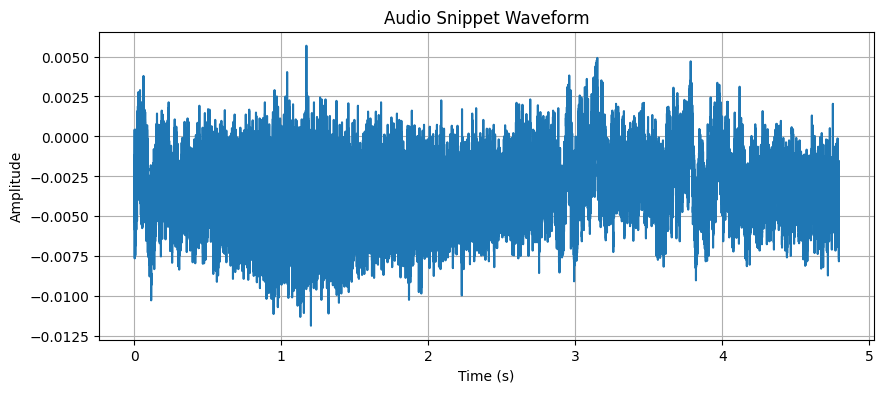

In [9]:
# plot the audio of a snippet to verify
import matplotlib.pyplot as plt
import numpy as np

snippet_file = "/mnt/fscompute_shared/simulation_dataset/events/channelA_2022-01-26_22-20-06_snippet_126_129.wav"
data, fs = sf.read(snippet_file)
time = np.arange(len(data)) / fs
plt.figure(figsize=(10, 4))
plt.plot(time, data)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Audio Snippet Waveform")
plt.grid()
plt.show()

# Make background snippets

In [37]:
folder_backgrounds = "/mnt/fscompute_shared/simulation_dataset/backgrounds"
df_backgrounds = merge_selection(FOLDER_ANNOTATIONS, mode="background")

len(df_backgrounds.Path.unique())

98

In [38]:
testfolder = "/data/bram.cuyx/Gitlab/uw-sim/demo"
for index, row in df_backgrounds.iterrows():
    write_snippet_background(row, folder_backgrounds)

File /mnt/fscompute_shared/simulation_dataset/backgrounds/channelA_2022-04-02_13-07-50_snippet_0_10.wav already exists, skipping...
File /mnt/fscompute_shared/simulation_dataset/backgrounds/channelA_2022-11-07_06-39-12_snippet_35_45.wav already exists, skipping...
File /mnt/fscompute_shared/simulation_dataset/backgrounds/8343.240507084912_snippet_0_10.wav already exists, skipping...
File /mnt/fscompute_shared/simulation_dataset/backgrounds/channelA_2022-04-04_20-48-03_snippet_0_10.wav already exists, skipping...
File /mnt/fscompute_shared/simulation_dataset/backgrounds/channelA_2022-02-13_03-04-27_snippet_245_255.wav already exists, skipping...
File /mnt/fscompute_shared/simulation_dataset/backgrounds/channelA_2021-03-18_15-37-24_snippet_280_290.wav already exists, skipping...
File /mnt/fscompute_shared/simulation_dataset/backgrounds/channelA_2021-03-17_17-51-49_snippet_9_19.wav already exists, skipping...
File /mnt/fscompute_shared/simulation_dataset/backgrounds/channelA_2022-01-26_22